# Multi-Dimensional Dynamic Time Warping, clustering and optimisation

In [3]:
import pandas as pd
import numpy as np
df = pd.read_csv(r"C:\Users\sambe\OneDrive\Desktop\Univeristy work\Year 2\MDM 2 part 2\WorldSustainabilityDataset.csv")

print(f"Shape: {df.shape}")
print(f"Countries: {df['Country Code'].nunique()}")
print(f"Years: {sorted(df['Year'].unique())}")


Shape: (3287, 54)
Countries: 173
Years: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018)]


In [ ]:
# non numerical columns
meta_cols = ['Country Name', 'Country Code', 'Year', 'Continent',
             'Income Classification (World Bank Definition)',
             'Regime Type (RoW Measure Definition)',
             'World Regions (UN SDG Definition)']

# get only the columns with numerical metrics
metric_cols = [c for c in df.columns if c not in meta_cols]
print(f"Number of metric columns: {len(metric_cols)}")

#convert to intergers 
df[metric_cols] = df[metric_cols].apply(pd.to_numeric, errors='coerce')

# Check how much data is missing per metric
missing_pct = df[metric_cols].isnull().mean().sort_values(ascending=False)
print("\nTop 10 metrics by % missing:")
print(missing_pct.head(10).round(3))

Number of metric columns: 47

Top 10 metrics by % missing:
Gini index (World Bank estimate) - SI.POV.GINI                                                  0.604
Proportion of population below international poverty line (%) - SI_POV_DAY1 - 1.1.1             0.603
Proportion of population covered by at least a 3G mobile network (%) - IT_MOB_3GNTWK - 9.c.1    0.587
Unemployment rate, women (%) - SL_TLF_UEM - 8.5.2                                               0.451
Unemployment rate, male (%) - SL_TLF_UEM - 8.5.2                                                0.450
Prevalence of undernourishment (%) - SN_ITK_DEFC - 2.1.1                                        0.442
Proportion of population using basic drinking water services (%) - SP_ACS_BSRVH2O - 1.4.1       0.441
Children out of school (% of primary school age) - SE.PRM.UNER.ZS                               0.323
Primary completion rate, total (% of relevant age group) - SE.PRM.CMPT.ZS                       0.323
Automated teller machin

In [ ]:
# keep metrics with 30% plus in each metric
threshold = 0.30
selected_metrics = missing_pct[missing_pct < threshold].index.tolist()
print(f"Metrics kept (< {threshold*100:.0f}% missing): {len(selected_metrics)} out of {len(metric_cols)}")

#build time series matrix
df_sorted = df.sort_values(['Country Code', 'Year'])

country_ts = {}
for code, group in df_sorted.groupby('Country Code'):
    ts = group[selected_metrics].values  # shape: (num_years, num_metrics)
    country_ts[code] = ts

Metrics kept (< 30% missing): 37 out of 47

Example country: ABW
Time series shape: (19, 37)  (years x metrics)


In [ ]:
# normalise each metric to prevent improper scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_sorted[selected_metrics] = scaler.fit_transform(df_sorted[selected_metrics])

# drop the Nans
country_ts_norm = {}
for code, group in df_sorted.groupby('Country Code'):
    ts_df = group[selected_metrics].copy()
    # Interpolate missing values along the time axis, then forward/back fill edges
    ts_df = ts_df.interpolate(method='linear', axis=0).ffill().bfill().fillna(0)
    country_ts_norm[code] = ts_df.values  # shape: (num_years, num_metrics)

Example: ABW, shape: (19, 37)
Any NaNs remaining: False


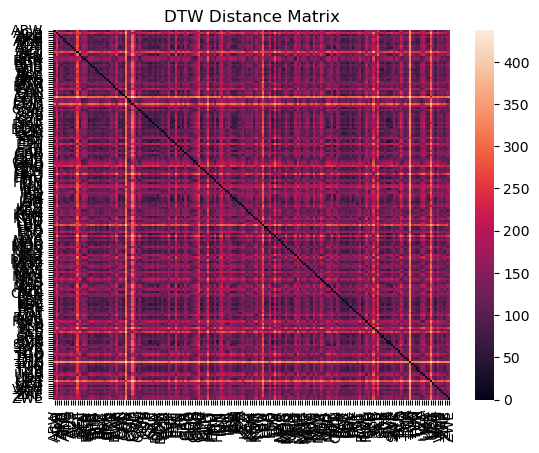

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# build the Dynamic time warping functions using euclidean distance
def cost_value(array_1, array_2):
    return np.sqrt(np.sum((array_1 - array_2)**2))
# dtw function
def DTW(series_1, series_2):
    N = len(series_1)
    M = len(series_2)
    cost_matrix = np.zeros((N, M))
    cost_matrix[0,0] = cost_value(series_1[0], series_2[0])

    for i in range(1,N):
        cost_matrix[i,0] = cost_value(series_1[i], series_2[0]) + cost_matrix[i-1, 0]
    
    for j in range(1,M):
        cost_matrix[0, j] = cost_value(series_1[0], series_2[j]) + cost_matrix[0, j-1]

    for i in range(1,N):
        for j in range(1,M):
            cost_matrix[i, j] = cost_value(series_1[i], series_2[j]) + np.min([cost_matrix[i-1, j], cost_matrix[i-1, j-1], cost_matrix[i, j-1]])
    return cost_matrix[N-1, M-1]

# for the country data

countries = list(country_ts_norm.keys())
n = len(countries)
dtw_dist = np.zeros((n, n))
for i in range(n):
    for j in range(i+1, n):
        dist = DTW(country_ts_norm[countries[i]], country_ts_norm[countries[j]])
        dtw_dist[i, j] = dist
        dtw_dist[j, i] = dist
# plot a distance matrix for the dtw
sns.heatmap(dtw_dist, xticklabels=countries, yticklabels=countries)
plt.title("DTW Distance Matrix")
plt.show()






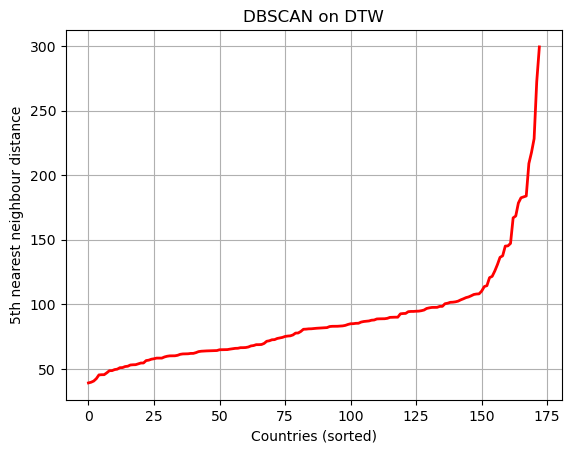

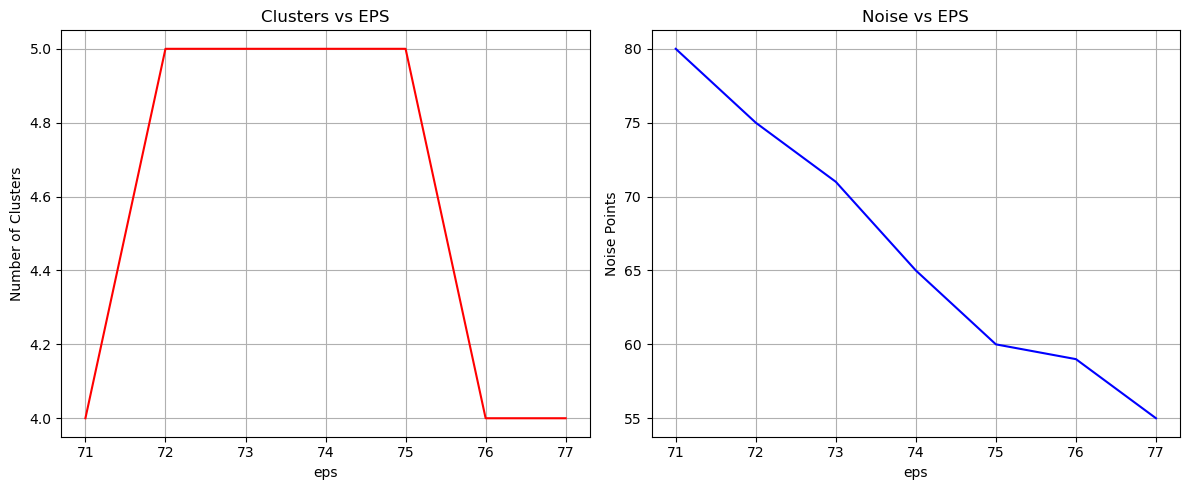

Optimal eps: 75 (5 clusters, 60 noise points)


In [ ]:
#DBSCAN
from sklearn.cluster import DBSCAN
from numpy import sort

k = 5  # same as min_samples
k_distances = sort(dtw_dist, axis=1)[:, k]


plt.plot(np.sort(k_distances), color = 'red', linewidth = 2)
plt.title('DBSCAN on DTW')
plt.ylabel(f'{k}th nearest neighbour distance')
plt.xlabel('Countries (sorted)')
plt.grid(True)
plt.show()


# find optimal eps for dbscan
eps_1 = []
clusters_1 = []
noise_1 = []


for eps in [71,72,73,74,75,76,77]:
    clustering = DBSCAN(eps=eps, min_samples=3, metric='precomputed').fit(dtw_dist)
    n_clusters = len(set(clustering.labels_)) - (1 if -1 in clustering.labels_ else 0)
    noise = np.sum(clustering.labels_ == -1)
    eps_1.append(eps)
    clusters_1.append(n_clusters)
    noise_1.append(noise)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(eps_1, clusters_1, color='red')
ax1.set_title('Clusters vs EPS')
ax1.set_xlabel('eps')
ax1.set_ylabel('Number of Clusters')
ax1.grid(True)

ax2.plot(eps_1, noise_1, color='blue')
ax2.set_title('Noise vs EPS')
ax2.set_xlabel('eps')
ax2.set_ylabel('Noise Points')
ax2.grid(True)

plt.tight_layout()
plt.show()

max_clusters = max(clusters_1)
best_eps = None
lowest_noise = float('inf')

for i in range(len(eps_1)):
    if clusters_1[i] == max_clusters and noise_1[i] < lowest_noise:
        lowest_noise = noise_1[i]
        best_eps = eps_1[i]

print(f"Optimal eps: {best_eps} ({max_clusters} clusters, {lowest_noise} noise points)")



In [9]:
# Final DBSCAN with optimal eps

clustering = DBSCAN(eps=best_eps, min_samples=3, metric='precomputed').fit(dtw_dist)
n_clusters = len(set(clustering.labels_)) - (1 if -1 in clustering.labels_ else 0)
noise = np.sum(clustering.labels_ == -1)

sorted_clusters_labels = [int(i) for i in np.unique(np.sort(clustering.labels_))]
print(sorted_clusters_labels)

clusters = []

for i in sorted_clusters_labels:
    cluster = []
    for j in range(len(countries)):#
        if i == clustering.labels_[j]:
            cluster.append(countries[j])
    clusters.append(cluster)


code_to_name = df.drop_duplicates('Country Code').set_index('Country Code')['Country Name'].to_dict()

for i in range(len(sorted_clusters_labels)):
    label = sorted_clusters_labels[i]
    names = [code_to_name[code] for code in clusters[i]]
    if label == -1:
        print(f"Noise ({len(names)} countries): {names}")
    else:
        print(f"Cluster {label} ({len(names)} countries): {names}")

[-1, 0, 1, 2, 3, 4]
Noise (60 countries): ['Angola', 'Burundi', 'Bangladesh', 'Bhutan', 'Central African Republic', 'China', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Cuba', 'Algeria', 'Eritrea', 'Ethiopia', 'Gabon', 'Guinea-Bissau', 'Equatorial Guinea', 'Guyana', 'Hong Kong SAR, China', 'Indonesia', 'India', 'Iraq', 'Jordan', 'Kyrgyz Republic', 'Cambodia', 'Lao PDR', 'Lebanon', 'Liberia', 'Lesotho', 'Luxembourg', 'Macao SAR, China', 'Malta', 'Myanmar', 'Mongolia', 'Mozambique', 'Mauritania', 'Malawi', 'Namibia', 'Nepal', 'Oman', 'Pakistan', "Korea, Dem. People's Rep.", 'West Bank and Gaza', 'Rwanda', 'Singapore', 'Solomon Islands', 'Sierra Leone', 'Suriname', 'Eswatini', 'Chad', 'Togo', 'Tajikistan', 'Timor-Leste', 'Tonga', 'Tanzania', 'Uganda', 'Ukraine', 'United States', 'Uzbekistan', 'Venezuela, RB', 'Vanuatu', 'Zimbabwe']
Cluster 0 (91 countries): ['Aruba', 'Albania', 'Argentina', 'Armenia', 'Antigua and Barbuda', 'Australia', 'Austria', 'Azerbaijan', 'Belgium', 'Bulgaria', 'Bahamas, Th

c:\Users\sambe\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


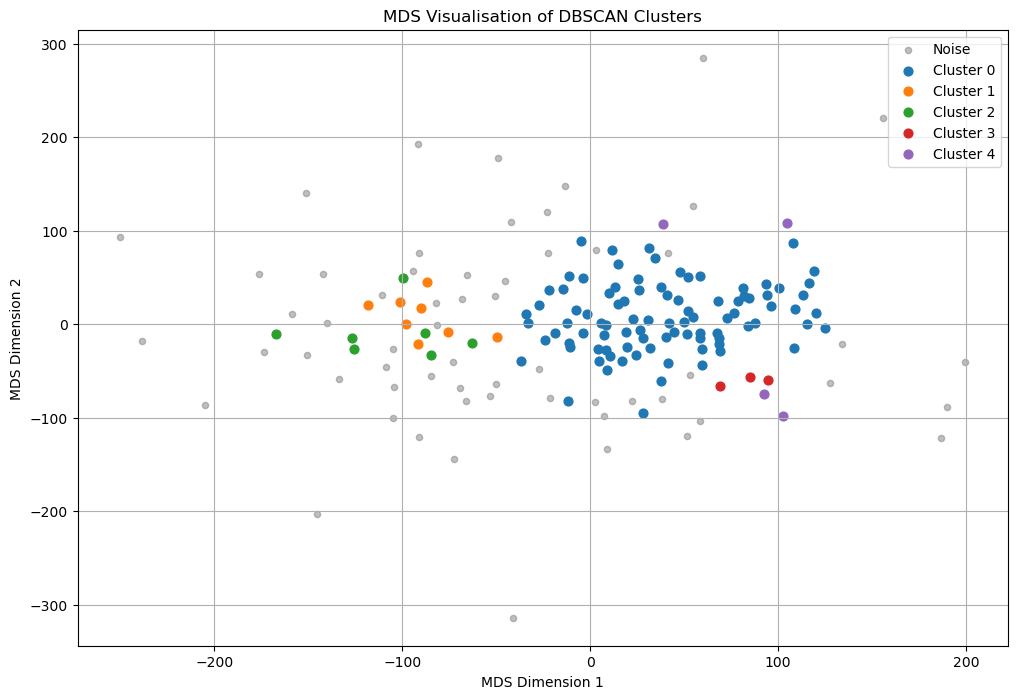

In [74]:
from sklearn.manifold import MDS

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
coords = mds.fit_transform(dtw_dist)

plt.figure(figsize=(12, 8))

for label in sorted(set(clustering.labels_)):
    mask = clustering.labels_ == label
    if label == -1:
        plt.scatter(coords[mask, 0], coords[mask, 1], c='grey', label='Noise', alpha=0.5, s=20)
    else:
        plt.scatter(coords[mask, 0], coords[mask, 1], label=f'Cluster {label}', s=40)

plt.title('MDS Visualisation of DBSCAN Clusters')
plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.legend()
plt.grid(True)
plt.show()


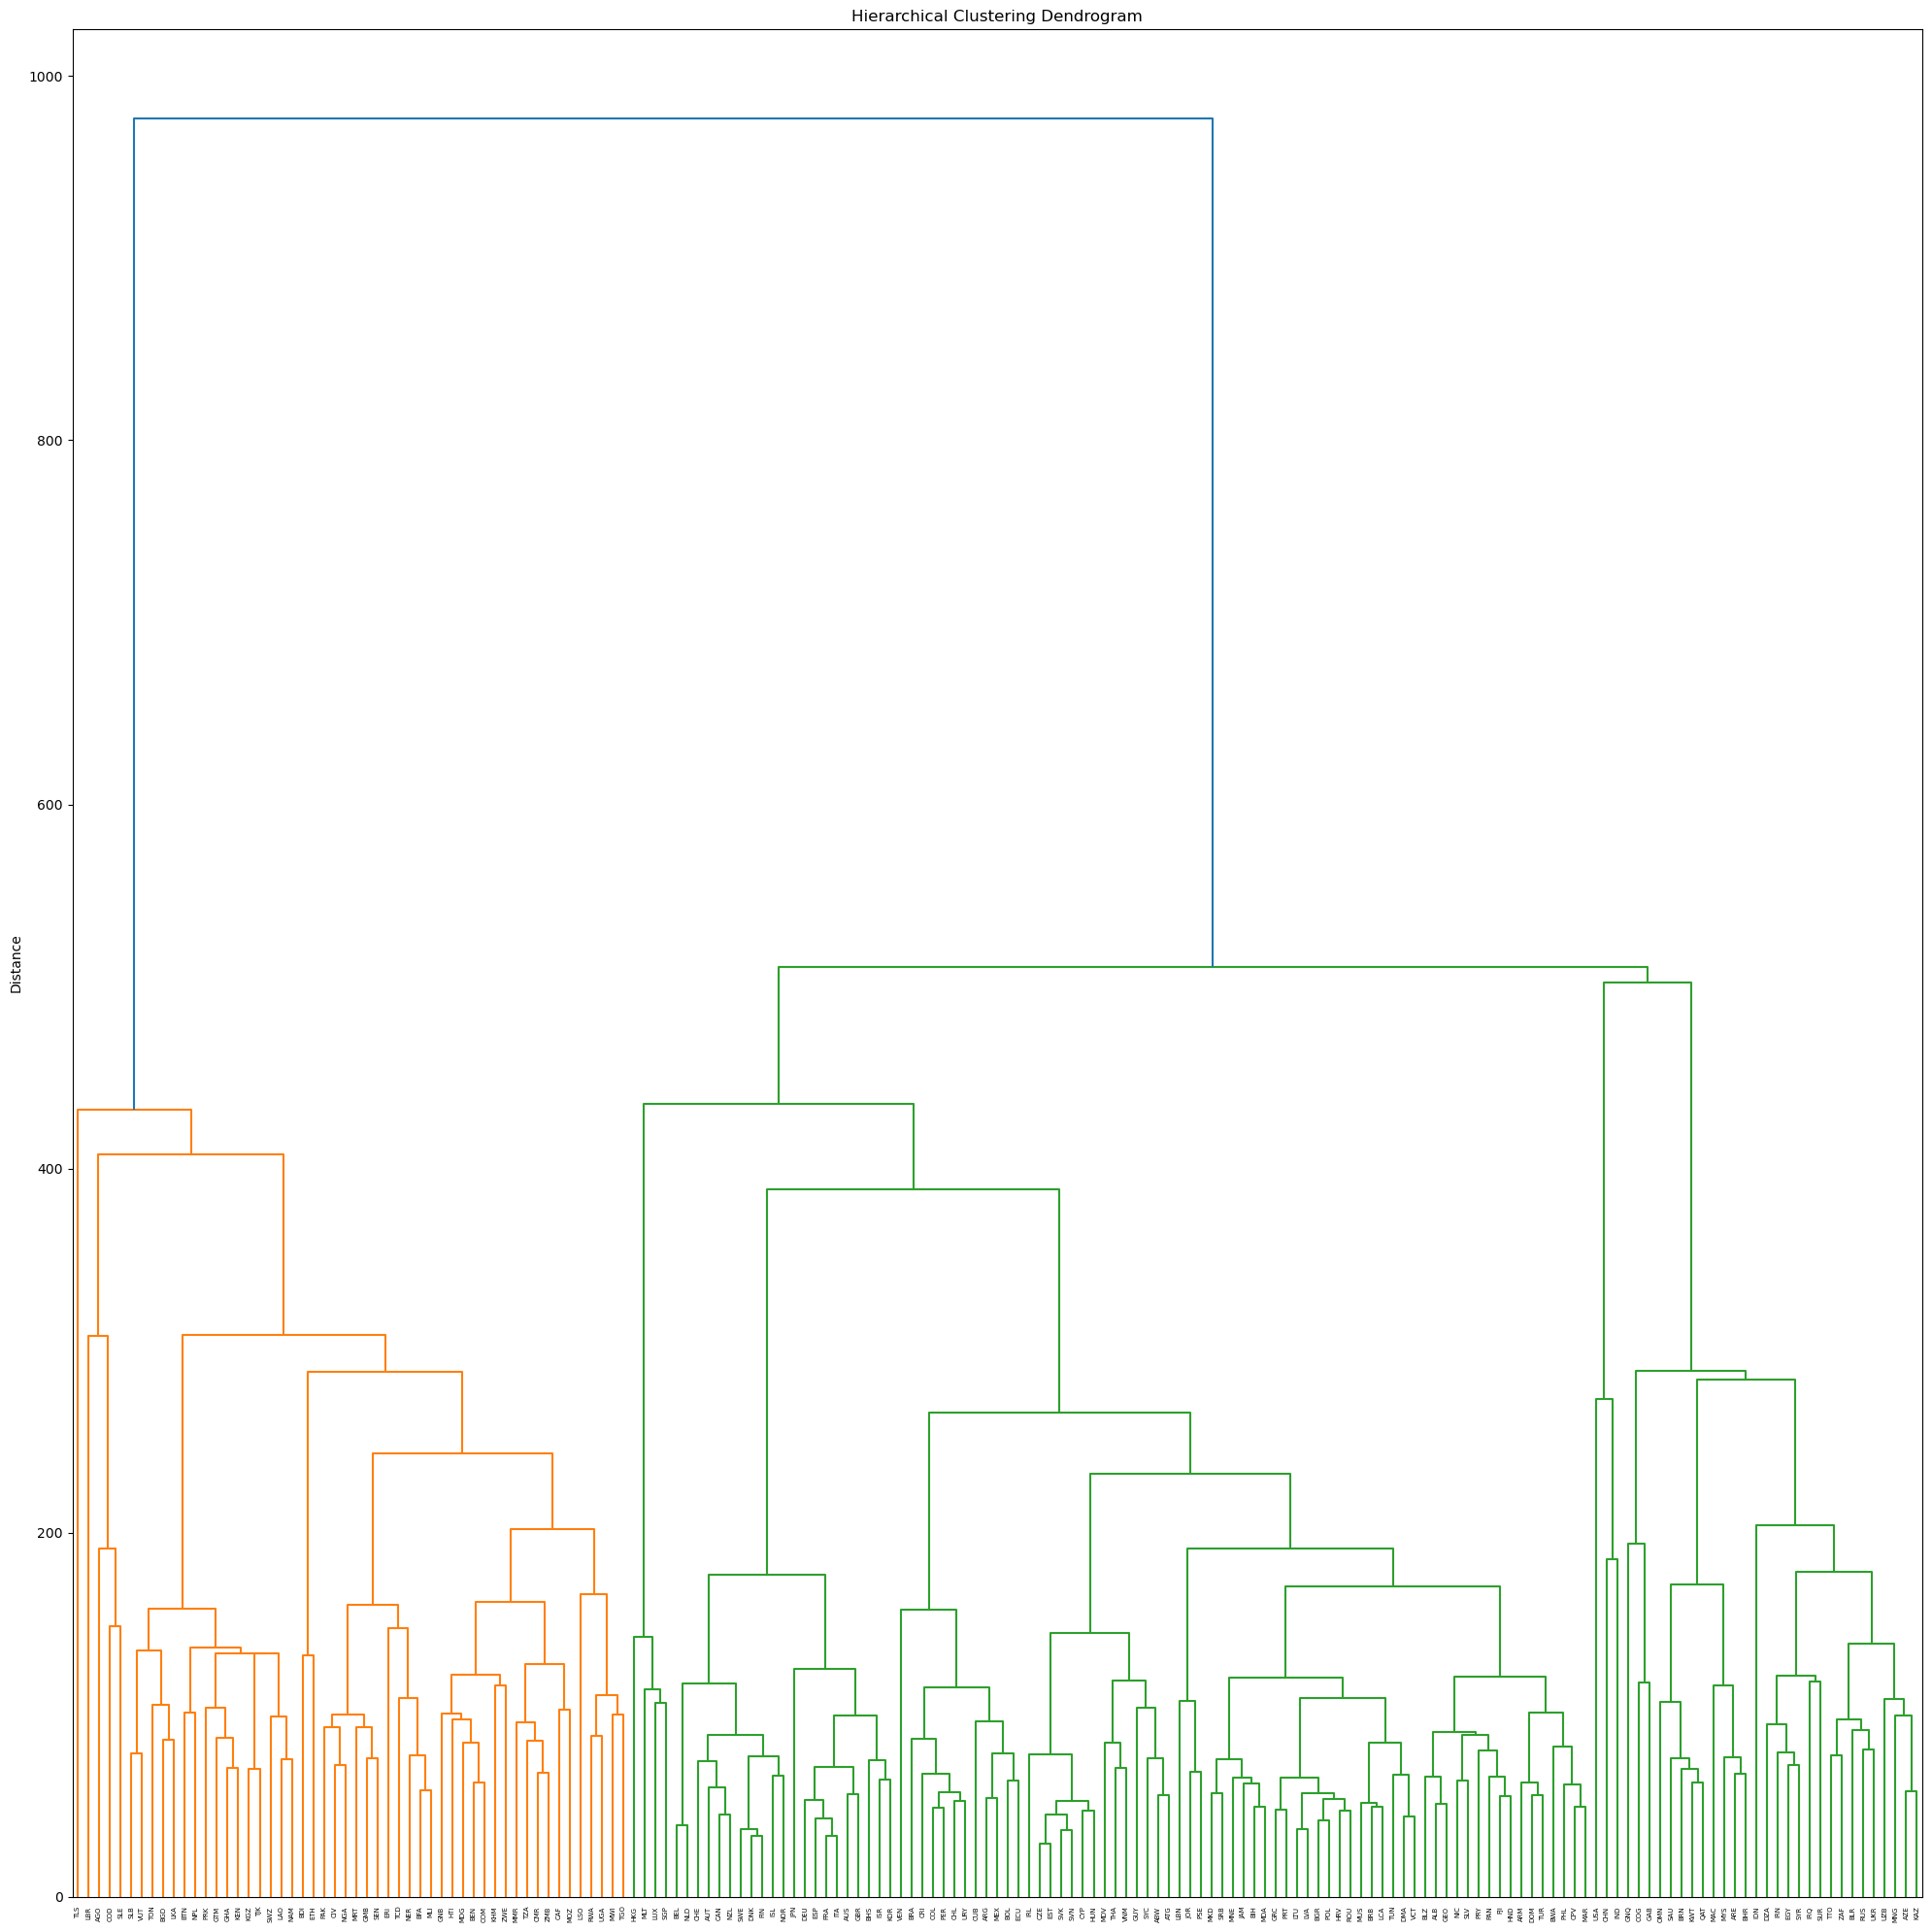

Cluster 1: 3 countries
['Angola', 'Congo, Dem. Rep.', 'Sierra Leone']

Cluster 2: 1 countries
['Liberia']

Cluster 3: 16 countries
['Bangladesh', 'Bhutan', 'Ghana', 'Guatemala', 'Kenya', 'Kyrgyz Republic', 'Lao PDR', 'Sri Lanka', 'Namibia', 'Nepal', "Korea, Dem. People's Rep.", 'Solomon Islands', 'Eswatini', 'Tajikistan', 'Tonga', 'Vanuatu']

Cluster 4: 2 countries
['Burundi', 'Ethiopia']

Cluster 5: 29 countries
['Benin', 'Burkina Faso', 'Central African Republic', "Cote d'Ivoire", 'Cameroon', 'Comoros', 'Eritrea', 'Gambia, The', 'Guinea-Bissau', 'Haiti', 'Cambodia', 'Lesotho', 'Madagascar', 'Mali', 'Myanmar', 'Mozambique', 'Mauritania', 'Malawi', 'Niger', 'Nigeria', 'Pakistan', 'Rwanda', 'Senegal', 'Chad', 'Togo', 'Tanzania', 'Uganda', 'Zambia', 'Zimbabwe']

Cluster 6: 1 countries
['Timor-Leste']

Cluster 7: 4 countries
['Hong Kong SAR, China', 'Luxembourg', 'Malta', 'Singapore']

Cluster 8: 21 countries
['Australia', 'Austria', 'Belgium', 'Bahamas, The', 'Canada', 'Switzerland', 'Ge

In [36]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

# into a square shape
condensed_dist = squareform(dtw_dist)

# Perform hierarchical clustering 
linked = linkage(condensed_dist, method='ward')

# Plot the dendrogram
plt.figure(figsize=(20, 20))
dendrogram(linked, labels=countries, leaf_rotation=90, leaf_font_size=5)
plt.title('Hierarchical Clustering Dendrogram')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

n_clusters =12
cluster_labels = fcluster(linked, n_clusters, criterion='maxclust')

# Group countries by cluster
code_to_name = df.drop_duplicates('Country Code').set_index('Country Code')['Country Name'].to_dict()

clusters = []
for i in range(1, n_clusters + 1):
    cluster = []
    for j in range(len(countries)):
        if cluster_labels[j] == i:
            cluster.append(countries[j])
    clusters.append(cluster)
    
    names = [code_to_name[code] for code in cluster]
    print(f"Cluster {i}: {len(cluster)} countries")
    print(names)
    print()

target_countries = [
    'Qatar', 'Brunei Darussalam', 'Ireland', 'Singapore', 'North Macedonia',
    'Korea, Rep.', 'Austria', 'Malta', 'Germany', 'Denmark',
    'China', 'Switzerland', 'Uzbekistan', 'Australia', 'Norway',
    'Estonia', 'Hungary', 'Belgium', 'Israel', 'Netherlands',
    'Algeria', 'Ecuador', 'Nepal', 'Iceland', 'Panama',
    'Kazakhstan', 'Ethiopia', 'Latvia', 'Croatia', 'Bulgaria'
]
name_to_code = {v: k for k, v in code_to_name.items()}

cluster_counts = {}

for country in target_countries:
    code = name_to_code.get(country)
    
    for i in range(len(clusters)):
        if code in clusters[i]:
            print(f"{country} ({code}): Cluster {i+1}")
            cluster_counts[i+1] = cluster_counts.get(i+1, 0) + 1
            break

print("\n--- Cluster Summary ---")
print([(f"Cluster {k}", v) for k, v in sorted(cluster_counts.items())])


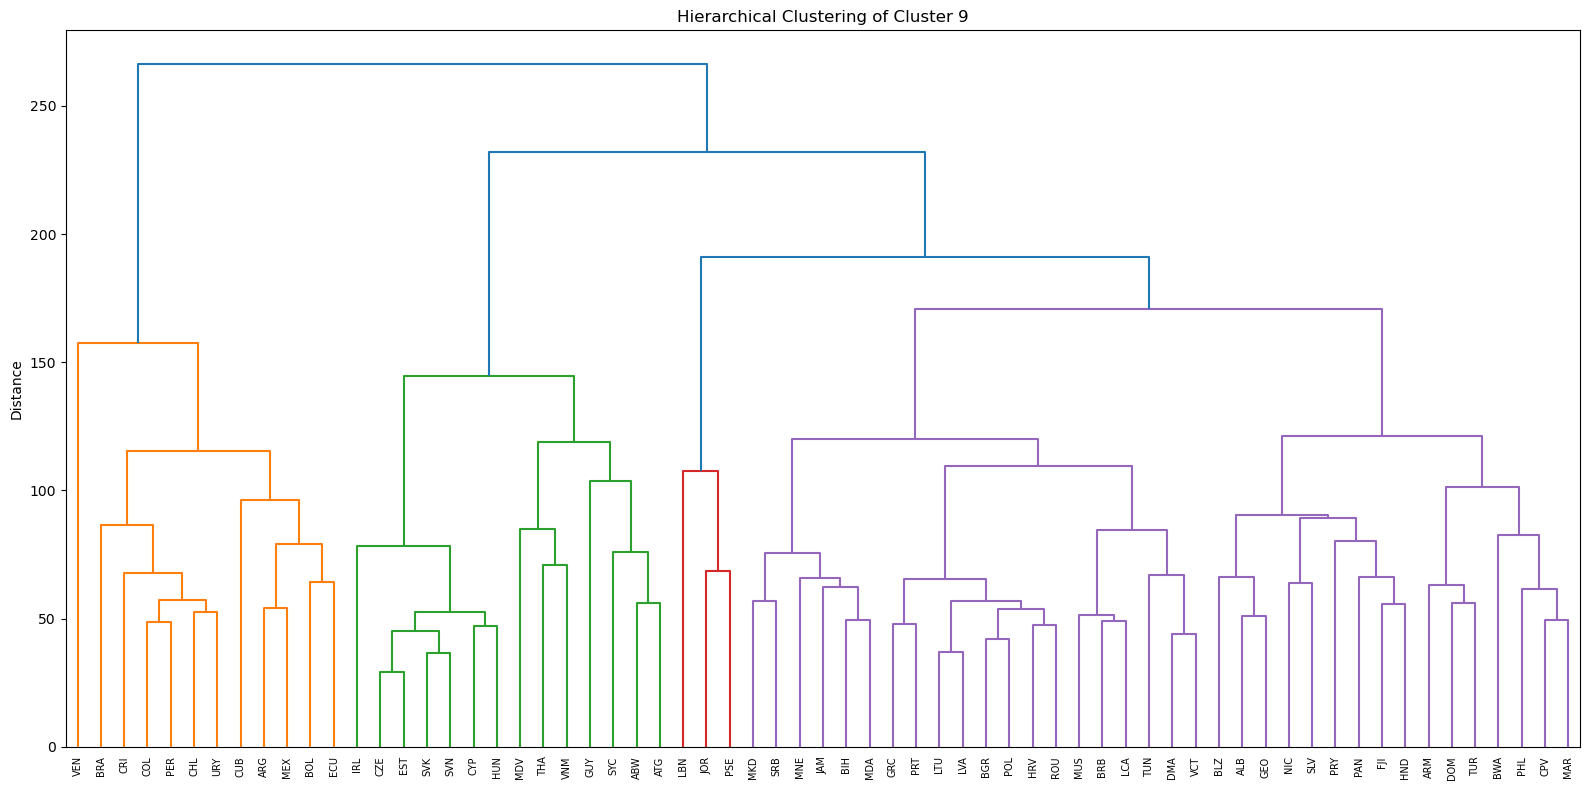

Sub-cluster 1: 12 countries
['Argentina', 'Bolivia', 'Brazil', 'Chile', 'Colombia', 'Costa Rica', 'Cuba', 'Ecuador', 'Mexico', 'Peru', 'Uruguay', 'Venezuela, RB']

Sub-cluster 2: 14 countries
['Aruba', 'Antigua and Barbuda', 'Cyprus', 'Czech Republic', 'Estonia', 'Guyana', 'Hungary', 'Ireland', 'Maldives', 'Slovak Republic', 'Slovenia', 'Seychelles', 'Thailand', 'Vietnam']

Sub-cluster 3: 3 countries
['Jordan', 'Lebanon', 'West Bank and Gaza']

Sub-cluster 4: 20 countries
['Bulgaria', 'Bosnia and Herzegovina', 'Barbados', 'Dominica', 'Greece', 'Croatia', 'Jamaica', 'St. Lucia', 'Lithuania', 'Latvia', 'Moldova', 'North Macedonia', 'Montenegro', 'Mauritius', 'Poland', 'Portugal', 'Romania', 'Serbia', 'Tunisia', 'St. Vincent and the Grenadines']

Sub-cluster 5: 16 countries
['Albania', 'Armenia', 'Belize', 'Botswana', 'Cabo Verde', 'Dominican Republic', 'Fiji', 'Georgia', 'Honduras', 'Morocco', 'Nicaragua', 'Panama', 'Philippines', 'Paraguay', 'El Salvador', 'Turkey']

Armenia (ARM): Clus

In [ ]:
cluster9_codes = clusters[8]  
cluster9_indices = [countries.index(code) for code in cluster9_codes]

sub_dist = dtw_dist[np.ix_(cluster9_indices, cluster9_indices)]

# Run hierarchical clustering on this sub-matrix
sub_condensed = squareform(sub_dist)
sub_linked = linkage(sub_condensed, method='ward')

# Plot the sub-dendrogram
plt.figure(figsize=(16, 8))
dendrogram(sub_linked, labels=cluster9_codes, leaf_rotation=90, leaf_font_size=7)
plt.title('Hierarchical Clustering of Cluster 9')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

n_sub = 5  
sub_labels = fcluster(sub_linked, n_sub, criterion='maxclust')

for i in range(1, n_sub + 1):
    members = [cluster9_codes[j] for j in range(len(cluster9_codes)) if sub_labels[j] == i]
    names = [code_to_name[code] for code in members]
    print(f"Sub-cluster {i}: {len(members)} countries")
    print(names)
    print()

target_countries = [
    'Qatar', 'Brunei Darussalam', 'Ireland', 'Singapore', 'North Macedonia',
    'Korea, Rep.', 'Austria', 'Malta', 'Germany', 'Denmark',
    'China', 'Switzerland', 'Uzbekistan', 'Australia', 'Norway',
    'Estonia', 'Hungary', 'Belgium', 'Israel', 'Netherlands',
    'Algeria', 'Ecuador', 'Nepal', 'Iceland', 'Panama',
    'Kazakhstan', 'Ethiopia', 'Latvia', 'Croatia', 'Bulgaria'
]
name_to_code = {v: k for k, v in code_to_name.items()}

for country in target_countries:
    code = name_to_code.get(country)
    if code is None:
        print(f"{country}: not found")
        continue
    
    if code in cluster9_codes:
        idx = cluster9_codes.index(code)
        sub_cluster = sub_labels[idx]
        print(f"{country} ({code}): Cluster 9 -> Sub-cluster {sub_cluster}")
    else:
        for i in range(len(clusters)):
            if code in clusters[i]:
                print(f"{country} ({code}): Cluster {i+1}")
                break

c:\Users\sambe\anaconda3\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


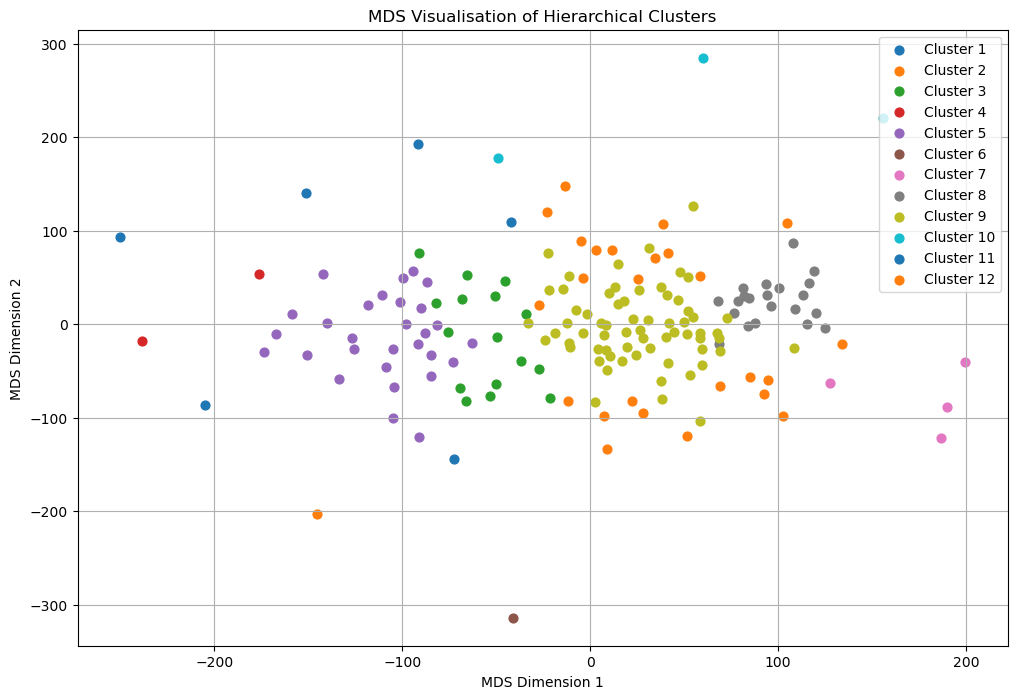

In [38]:
from sklearn.manifold import MDS

mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
coords = mds.fit_transform(dtw_dist)


plt.figure(figsize=(12, 8))

for label in sorted(set(cluster_labels)):
    mask = cluster_labels == label
    plt.scatter(coords[mask, 0], coords[mask, 1], label=f'Cluster {label}', s=40)

plt.title('MDS Visualisation of Hierarchical Clusters')
plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.legend()
plt.grid(True)
plt.show()
